# **Message Intelligence System**

- ## Importing Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

- ### Dataset

In [2]:
data = pd.read_csv("Message_Intelligence_Dataset.csv")
data.head()

,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0


In [3]:
# Describe
data.describe()

,message_id,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week,spam_label
count,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5094.000000,5087.000000,5038.000000,5200.000000,5200.000000,5200.000000
mean,902600.500000,75.035962,11.457308,0.206538,1.681346,0.243654,0.246346,0.817692,54.836317,296.671909,8.301906,11.523462,3.038846,0.187115
std,1501.255031,12.455377,1.609056,0.404860,2.415846,0.545363,0.676798,0.556687,17.697943,191.748754,5.586503,6.861518,2.062504,0.390042
min,900001.000000,32.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,901300.750000,67.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,43.100000,148.000000,5.000000,6.000000,1.000000,0.000000
50%,902600.500000,74.000000,11.000000,0.000000,0.000000,0.000000,0.000000,1.000000,54.800000,275.000000,7.000000,12.000000,3.000000,0.000000
75%,903900.250000,81.000000,13.000000,0.000000,4.000000,0.000000,0.000000,1.000000,66.600000,410.500000,10.000000,17.000000,5.000000,0.000000
max,905200.000000,122.000000,16.000000,1.000000,9.000000,2.000000,3.000000,2.000000,100.000000,1500.000000,38.000000,23.000000,6.000000,1.000000


In [4]:
# Info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   message_id               5200 non-null   int64  
 1   message_text             5200 non-null   object 
 2   message_length           5200 non-null   int64  
 3   word_count               5200 non-null   int64  
 4   num_urls                 5200 non-null   int64  
 5   num_digits               5200 non-null   int64  
 6   num_special_chars        5200 non-null   int64  
 7   spam_keyword_score       5200 non-null   int64  
 8   legit_keyword_score      5200 non-null   int64  
 9   sender_activity_score    5094 non-null   float64
 10  sender_account_age_days  5087 non-null   float64
 11  messages_sent_last_24h   5038 non-null   float64
 12  timestamp                5200 non-null   object 
 13  hour_of_day              5200 non-null   int64  
 14  day_of_week             

In [5]:
# Isnull
data.isnull().sum()

message_id                   0
message_text                 0
message_length               0
word_count                   0
num_urls                     0
num_digits                   0
num_special_chars            0
spam_keyword_score           0
legit_keyword_score          0
sender_activity_score      106
sender_account_age_days    113
messages_sent_last_24h     162
timestamp                    0
hour_of_day                  0
day_of_week                  0
spam_label                   0
dtype: int64

In [6]:
# Coverting the date column into meaningfull column
data["timestamp"] = pd.to_datetime(data["timestamp"])
data["time"] = data["timestamp"].dt.time
data["day"] = data["timestamp"].dt.day
data["month"] = data["timestamp"].dt.month
data["year"] = data["timestamp"].dt.year

In [7]:
# Dropping the unnecessary feature
data.drop("message_id", axis= 1, inplace= True)
data.drop("timestamp", axis= 1, inplace= True)
data.drop("message_text", axis= 1, inplace= True)
data.drop("time", axis= 1, inplace= True)

In [8]:
# Creating the mean median imputer
from sklearn.impute import SimpleImputer
mean = SimpleImputer(strategy= "mean")
median = SimpleImputer(strategy= "median")

data["sender_activity_score"] = mean.fit_transform(data[["sender_activity_score"]])
data[["sender_account_age_days", "messages_sent_last_24h"]] = median.fit_transform(data[["sender_account_age_days", "messages_sent_last_24h"]])

## **Part B: Dataset Understanding & Preparation**

### 6. Identify input features and target variable.

In [9]:
x = data.drop("spam_label", axis= 1)
y = data["spam_label"]

### 7. Perform basic data preprocessing (scaling where required).

In [10]:
for i in data.select_dtypes(include= "number").columns:
    print(i, min(data[i]), max(data[i]))

message_length 32 122
word_count 5 16
num_urls 0 1
num_digits 0 9
num_special_chars 0 2
spam_keyword_score 0 3
legit_keyword_score 0 2
sender_activity_score 5.0 100.0
sender_account_age_days 2.0 1500.0
messages_sent_last_24h 0.0 38.0
hour_of_day 0 23
day_of_week 0 6
spam_label 0 1
day 1 31
month 10 12
year 2025 2025


In [11]:
# Creating standard and min-max scaler
from sklearn.preprocessing import StandardScaler, MinMaxScaler
std_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()

data["sender_activity_score"] = std_scaler.fit_transform(data[["sender_activity_score"]])
data["sender_account_age_days "] = min_max_scaler.fit_transform(data[["sender_account_age_days"]])
data["messages_sent_last_24h"] = std_scaler.fit_transform(data[["messages_sent_last_24h"]])
data["messages_sent_last_24h"] = std_scaler.fit_transform(data[["messages_sent_last_24h"]])

### 8. Split the dataset into training and testing sets.

In [12]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2)

## **Part C: Baseline Model - K-Nearest Neighbors**

### 9. Implement K-Nearest Neighbors (KNN) classifier.

Implementaion will be done below!

### 10. Experiment with different values of K.

In [13]:
from imblearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import ADASYN
k_values = [1, 3, 5, 7, 9]
for k in k_values:
    knn_pipeline = Pipeline([
        ("knn", KNeighborsClassifier(n_neighbors= k))])
    knn_pipeline.fit(x_train, y_train)
    y_pred = knn_pipeline.predict(x_test)

In [14]:
# Evaluation of this model
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
print(f"Accuracy Score : {accuracy_score(y_test,y_pred)}")
print(f"Recall Score : {recall_score(y_test,y_pred)}")
print(f"Precision Score : {precision_score(y_test,y_pred)}")
print(f"F1-Score : {f1_score(y_test,y_pred)}")
print(f"Confusion Matrix : \n{confusion_matrix(y_test,y_pred)}")

Accuracy Score : 0.9538461538461539
Recall Score : 0.8043478260869565
Precision Score : 0.925
F1-Score : 0.8604651162790697
Confusion Matrix : 
[[844  12]
 [ 36 148]]


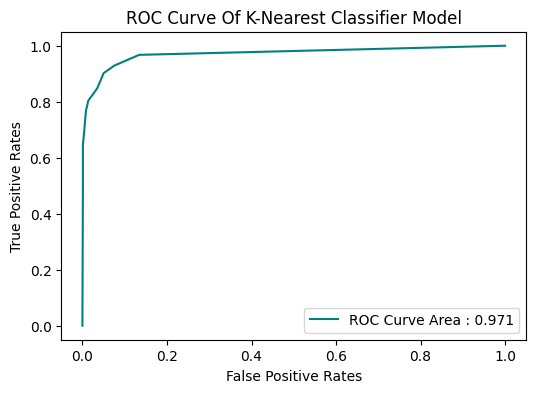

In [15]:
y_prob_knn = knn_pipeline.predict_proba(x_test)[:,1]

# Computing ROC Values
fpr,tpr,threshold = roc_curve(y_test,y_prob_knn)

plt.figure(figsize=(6,4))
plt.plot(fpr,tpr,label=f"ROC Curve Area : {roc_auc_score(y_test,y_prob_knn):.3f}",color="teal")
plt.title("ROC Curve Of K-Nearest Classifier Model")
plt.xlabel("False Positive Rates")
plt.ylabel("True Positive Rates")
plt.legend(loc="lower right")
plt.show()

### 11. Analyze how distance metrics affect predictions.

In [16]:
metrices = ["euclidean", "manhattan", "minkowski"]
for m in metrices:
    knn_metri = KNeighborsClassifier(n_neighbors= 5, metric= m)
    knn_metri.fit(x_train, y_train)
    y_pred_metri = knn_metri.predict(x_test)

### 12. Identify cases where KNN misclassifies messages.

In [17]:
results = pd.DataFrame({"Actual": y_test,"Predicted": y_pred})

# Get Misclassified Rows
misclassified = results[results["Actual"] != results["Predicted"]]

# Showing Total Number Of Cases Wrongly Predicted
print(f"Number Of Cases : {misclassified["Predicted"].count()}\n")
print(f"Specific Places Where It Was Wrong :")
print(misclassified.head())

Number Of Cases : 48

Specific Places Where It Was Wrong :
      Actual  Predicted
5144       0          1
465        1          0
3338       1          0
3334       1          0
1048       1          0


## **Part D: Support Vector Machine Classifier**

### 13. Implement Support Vector Machine (SVM) classifier with:
- Linear kernel
- RBF or Polynomial kernel

In [24]:
from sklearn.svm import SVC
svc_pipe_li = Pipeline([
    ("svm", SVC(kernel = "linear"))
])
svc_pipe_li.fit(x_train, y_train)
y_pred_svc_li = svc_pipe_li.predict(x_test)

In [ ]:
# RBF
svc_pipe_rbf = Pipeline([
    ("svm", SVC(kernel = "rbf"))
])
svc_pipe_rbf.fit(x_train, y_train)
y_pred_svc_rbf = svc_pipe_rbf.predict(x_test)

In [ ]:
# Polynomial
svc_pipe_poly = Pipeline([
    ("svm", SVC(kernel = "poly", degree= 3))
])
svc_pipe_poly.fit(x_train, y_train)
y_pred_svc_poly = svc_pipe_poly.predict(x_test)

### 14. Analyze margin separation and support vectors.

In [28]:
svc = svc_pipe_li.named_steps["svm"]

print("Number of Support Vectors:", len(svc.support_vectors_))
print("Support Vector Indices:", svc.support_)

Number of Support Vectors: 13
Support Vector Indices: [ 330 1132 1384 1657 2272 2462 3114 3493 3877  159  239 1645 2476]


### 15. Compare SVM performance with KNN.

In [31]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("KNN")
y_pred_knn = knn_pipeline.predict(x_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nConfusion Matrix (KNN):")
print(confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report (KNN):")
print(classification_report(y_test, y_pred_knn))

KNN
KNN Accuracy: 0.9538461538461539

Confusion Matrix (KNN):
[[844  12]
 [ 36 148]]

Classification Report (KNN):
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       856
           1       0.93      0.80      0.86       184

    accuracy                           0.95      1040
   macro avg       0.94      0.90      0.92      1040
weighted avg       0.95      0.95      0.95      1040



In [32]:
print("SVC")
y_pred_svm = svc_pipe_li.predict(x_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nConfusion Matrix (SVM):")
print(confusion_matrix(y_test, y_pred_svm))

print("\nClassification Report (SVM):")
print(classification_report(y_test, y_pred_svm))

SVC
SVM Accuracy: 1.0

Confusion Matrix (SVM):
[[856   0]
 [  0 184]]

Classification Report (SVM):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       856
           1       1.00      1.00      1.00       184

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



## **Part E: Naive Bayes Classifier & Probability**

### 16. Implement Naive Bayes Classifier.

In [34]:
from sklearn.naive_bayes import GaussianNB
nb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("nb", GaussianNB())
])
nb_pipeline.fit(x_train, y_train)
y_pred_nb = nb_pipeline.predict(x_test)

### 17. Manually compute conditional probabilities for a few sample messages.

In [37]:
spam_count = (data["spam_label"] == 1).sum()
legit_count = (data["spam_label"] == 0).sum()

total = len(data)

P_spam = spam_count / total
P_legit = legit_count / total

print("P(Spam):", P_spam)
print("P(Legit):", P_legit)

P_urls_given_spam = data[data["spam_label"] == 1]["num_urls"].mean()
P_urls_given_legit = data[data["spam_label"] == 0]["num_urls"].mean()

print("Average URLs in Spam:", P_urls_given_spam)
print("Average URLs in Legit:", P_urls_given_legit)

P(Spam): 0.18711538461538463
P(Legit): 0.8128846153846154
Average URLs in Spam: 0.7389516957862282
Average URLs in Legit: 0.08398391294061983


### 18. Demonstrate how Bayes' Theorem is applied to compute class probabilities.

Bayes’ theorem is used in Naive Bayes classification to compute the probability of a class given observed features. By combining prior probabilities and feature likelihoods, the classifier determines the most probable class. In spam detection, this helps identify whether a message is spam or legitimate based on message characteristics.

### 19. Compare theoretical probability calculations with model predictions.

In [39]:
y_pred_nb = nb_pipeline.predict(x_test)

print(y_pred_nb[:10])

probabilities = nb_pipeline.predict_proba(x_test)

print(probabilities[:5])

[0 0 0 0 0 1 0 0 0 0]
[[1.00000000e+00 0.00000000e+00]
 [1.00000000e+00 0.00000000e+00]
 [1.00000000e+00 0.00000000e+00]
 [9.99999931e-01 6.85960744e-08]
 [9.99999998e-01 1.57357333e-09]]


Theoretical probabilities calculated using Bayes’ theorem were compared with predictions generated by the Naive Bayes classifier. The results show that the model predictions follow the same probabilistic principles as manual calculations. Small differences occur because the model considers multiple features simultaneously while manual calculations typically use fewer features.

## **Part F: Model Comparison & Evaluation**

### 20. Evaluate all models using appropriate classification metrics:
- Accuracy
- Precision
- Recall
- F1 Score

In [40]:
results = {
    "Model": ["KNN", "SVM", "Naive Bayes"],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_nb)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_nb)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_nb)
    ],
    
    "F1 Score": [
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_nb)
    ]
}

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.953846,0.925,0.804348,0.860465
1,SVM,1.000000,1.000,1.000000,1.000000
2,Naive Bayes,1.000000,1.000,1.000000,1.000000


### 21. Compare:
- KNN vs SVM vs Naive Bayes

| Aspect                 | KNN                                       | SVM                                 | Naive Bayes                                     |
| ---------------------- | ----------------------------------------- | ----------------------------------- | ----------------------------------------------- |
| Type                   | Distance-based                            | Margin-based                        | Probabilistic                                   |
| Working Principle      | Uses nearest neighbors for classification | Finds optimal separating hyperplane | Uses Bayes' theorem for probability calculation |
| Training Time          | Very low                                  | Moderate to high                    | Very fast                                       |
| Prediction Speed       | Slow for large datasets                   | Faster                              | Very fast                                       |
| Handling Complex Data  | Moderate                                  | Very good                           | Moderate                                        |
| Sensitivity to Scaling | High                                      | High                                | Low                                             |
| Interpretability       | Simple                                    | Moderate                            | Easy to understand                              |


### 22. Identify which model performs best for:
- High precision
- High recall

In [41]:
# Precision
precision_knn = precision_score(y_test, y_pred_knn)
precision_svm = precision_score(y_test, y_pred_svm)
precision_nb = precision_score(y_test, y_pred_nb)

# Recall
recall_knn = recall_score(y_test, y_pred_knn)
recall_svm = recall_score(y_test, y_pred_svm)
recall_nb = recall_score(y_test, y_pred_nb)

print("Precision Scores:")
print("KNN:", precision_knn)
print("SVM:", precision_svm)
print("Naive Bayes:", precision_nb)

print("\nRecall Scores:")
print("KNN:", recall_knn)
print("SVM:", recall_svm)
print("Naive Bayes:", recall_nb)
precision_scores = {
    "KNN": precision_knn,
    "SVM": precision_svm,
    "Naive Bayes": precision_nb
}

recall_scores = {
    "KNN": recall_knn,
    "SVM": recall_svm,
    "Naive Bayes": recall_nb
}

best_precision_model = max(precision_scores, key=precision_scores.get)
best_recall_model = max(recall_scores, key=recall_scores.get)

print("\nModel with Highest Precision:", best_precision_model)
print("Model with Highest Recall:", best_recall_model)

Precision Scores:
KNN: 0.925
SVM: 1.0
Naive Bayes: 1.0

Recall Scores:
KNN: 0.8043478260869565
SVM: 1.0
Naive Bayes: 1.0

Model with Highest Precision: SVM
Model with Highest Recall: SVM


## **Part G: Final Analysis & Reporting**(It's in the word file .docx)